# BCS 404: Introduction to Data Science with Python
## Project: Exploratory Data Analysis, Statistical Analysis and Machine Learning on the Titanic Dataset

**Accra Technical University — Department of Computer Science**
**Lecturer:** Dr. Joseph Dadzie | **Academic Year:** 2025/2026, Second Semester

This notebook implements Tasks 1–5 of the project brief: Data Acquisition, Data Cleaning, Data Visualisation, Statistical Analysis, and Machine Learning (Logistic Regression) on the Kaggle Titanic dataset.

## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Task 1: Data Acquisition

The dataset used is the **Titanic: Machine Learning from Disaster** dataset from Kaggle
(`https://www.kaggle.com/competitions/titanic/data`). The `train.csv` file (891 passenger
records, 12 columns) was downloaded and loaded below.

In [2]:
df = pd.read_csv("train.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Dataset dimensions
print(f"Dataset dimensions (rows, columns): {df.shape}")

Dataset dimensions (rows, columns): (891, 12)


In [4]:
# Column names
print("Column names:")
print(list(df.columns))

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [5]:
# First five observations
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Data types
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

**Interpretation:** The dataset contains 891 passenger records across 12 columns,
including the target variable `Survived` (0 = died, 1 = survived) and predictor variables
such as `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, and `Embarked`. Data types are a
mix of integers, floats, and objects (strings), which is expected for a dataset combining
numeric measurements with categorical/text fields.

## Task 2: Data Cleaning

### 2.1 Detect Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing Count", ascending=False)
missing_summary

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Observation:** Three columns contain missing values: `Cabin` (~77% missing), `Age`
(~20% missing), and `Embarked` (2 records missing).

### 2.2 Handle Missing Values

In [8]:
df_clean = df.copy()

# Age: impute with the median (robust to outliers, preserves distribution shape better than the mean)
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Embarked: impute with the mode, since only 2 values are missing out of 891
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Cabin: over 77% missing — the column itself is not reliably usable, so it is dropped
# rather than imputed, which would introduce substantial noise/bias
df_clean = df_clean.drop(columns=["Cabin"])

print("Remaining missing values per column:")
print(df_clean.isnull().sum())

Remaining missing values per column:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**Explanation of preprocessing decisions:**
- **`Age` (median imputation):** Age is numeric and right-skewed with some outliers (elderly
  passengers, infants). The median is less sensitive to outliers than the mean, so it was
  used to fill the ~177 missing values without distorting the distribution.
- **`Embarked` (mode imputation):** Only 2 of 891 records were missing this categorical field,
  so filling with the most frequent port of embarkation has negligible impact on the analysis.
- **`Cabin` (dropped):** With over three-quarters of values missing, any imputation strategy
  would be dominated by guesswork rather than signal, so the column was removed entirely
  instead of being imputed.

### 2.3 Detect and Remove Duplicates

In [9]:
duplicate_count = df_clean.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates removed. New shape: {df_clean.shape}")
else:
    print("No duplicate rows were found; no removal necessary.")

Number of duplicated rows: 0
No duplicate rows were found; no removal necessary.


**Explanation:** Each row represents a unique passenger identified by `PassengerId`,
so full-row duplicates would indicate a data entry error. The check found no duplicate rows,
which is expected given the dataset's construction, so no rows were removed.

## Task 3: Data Visualisation

Six required visualisations are produced below, each with a title, axis labels, and a brief interpretation.

### 3.1 Histogram of Passenger Ages

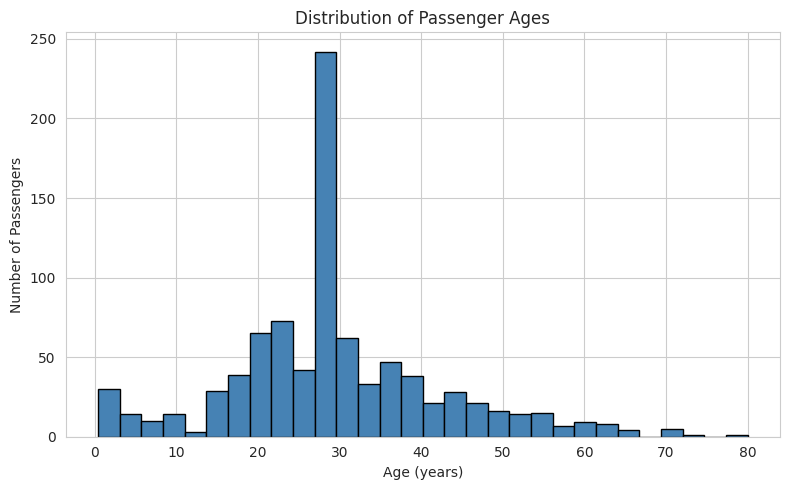

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Age"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age (years)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("figures/1_age_histogram.png", dpi=150)
plt.show()

**Interpretation:** The age distribution is right-skewed and concentrated between 20 and
40 years, with a noticeable spike around the median-imputed age (~28 years) due to missing
value imputation. Relatively few passengers were elderly (60+), and there is a distinguishable
cluster of infants and children under 10.

### 3.2 Bar Chart: Passenger Class Distribution

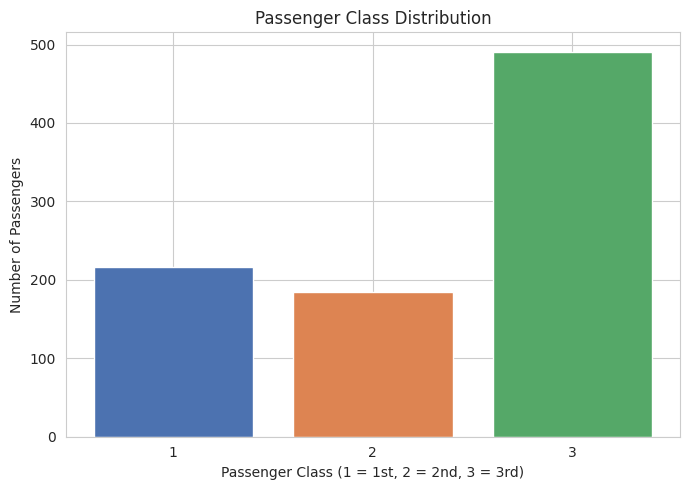

In [11]:
plt.figure(figsize=(7, 5))
class_counts = df_clean["Pclass"].value_counts().sort_index()
plt.bar(class_counts.index.astype(str), class_counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("figures/2_class_bar.png", dpi=150)
plt.show()

**Interpretation:** Third class passengers make up the largest group by a wide margin,
followed by first class and then second class. This reflects the Titanic's actual passenger
composition, where the majority of travellers held lower-cost tickets.

### 3.3 Boxplot of Age by Passenger Class

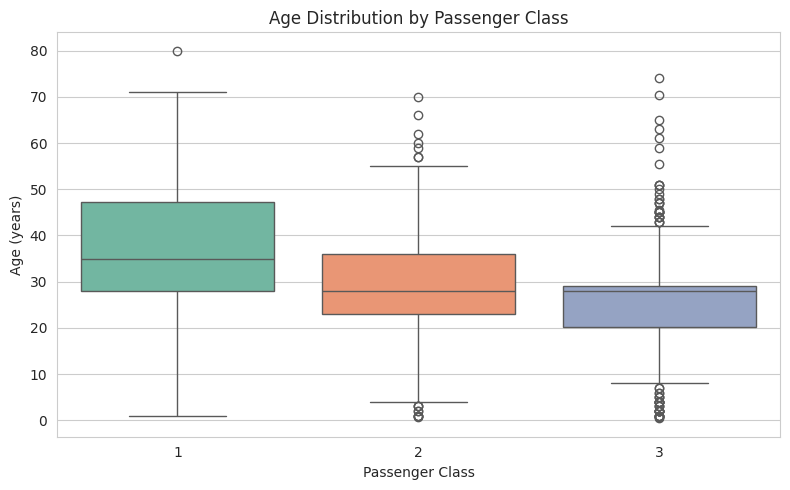

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Pclass", y="Age", data=df_clean, hue="Pclass", palette="Set2", legend=False)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.savefig("figures/3_age_by_class_boxplot.png", dpi=150)
plt.show()

**Interpretation:** Median age decreases as passenger class decreases: first class
passengers were, on average, older and wealthier, while third class passengers skew younger.
Several elderly outliers appear in first class.

### 3.4 Scatter Plot: Age vs Fare

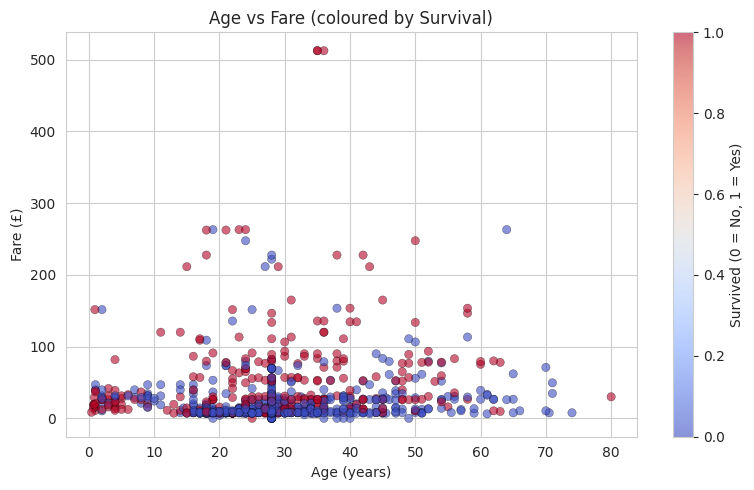

In [13]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df_clean["Age"], df_clean["Fare"],
                       c=df_clean["Survived"], cmap="coolwarm", alpha=0.6, edgecolor="k", linewidth=0.3)
plt.title("Age vs Fare (coloured by Survival)")
plt.xlabel("Age (years)")
plt.ylabel("Fare (£)")
plt.colorbar(scatter, label="Survived (0 = No, 1 = Yes)")
plt.tight_layout()
plt.savefig("figures/4_age_vs_fare_scatter.png", dpi=150)
plt.show()

**Interpretation:** Most passengers paid modest fares regardless of age, with a small
number of high-fare outliers. There is no strong linear relationship visible between age and
fare, but passengers who paid higher fares (likely first class) appear more concentrated among
survivors (warmer-coloured points).

### 3.5 Correlation Heatmap

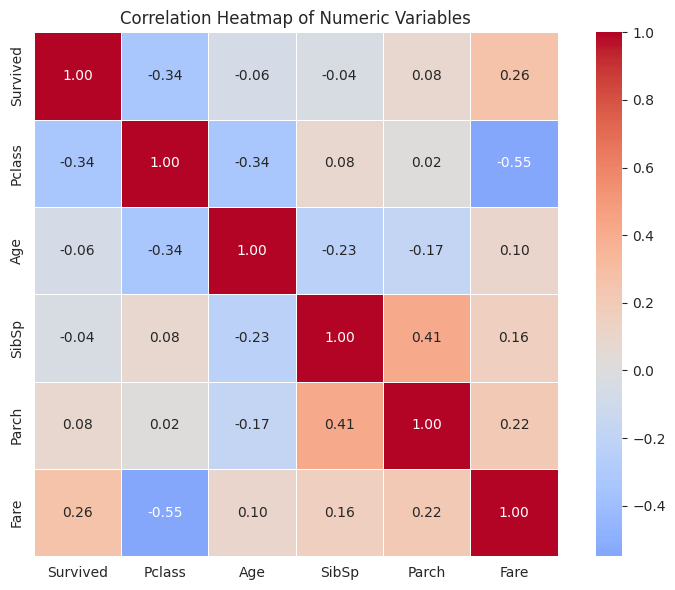

In [14]:
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.savefig("figures/5_correlation_heatmap.png", dpi=150)
plt.show()

**Interpretation:** `Pclass` and `Fare` show the strongest correlations with `Survived`
(negative and positive respectively), indicating that wealthier passengers in higher classes
had better survival odds. `SibSp` and `Parch` show weak positive correlation with each other,
reflecting family groups travelling together.

### 3.6 Pairplot of Selected Numerical Variables

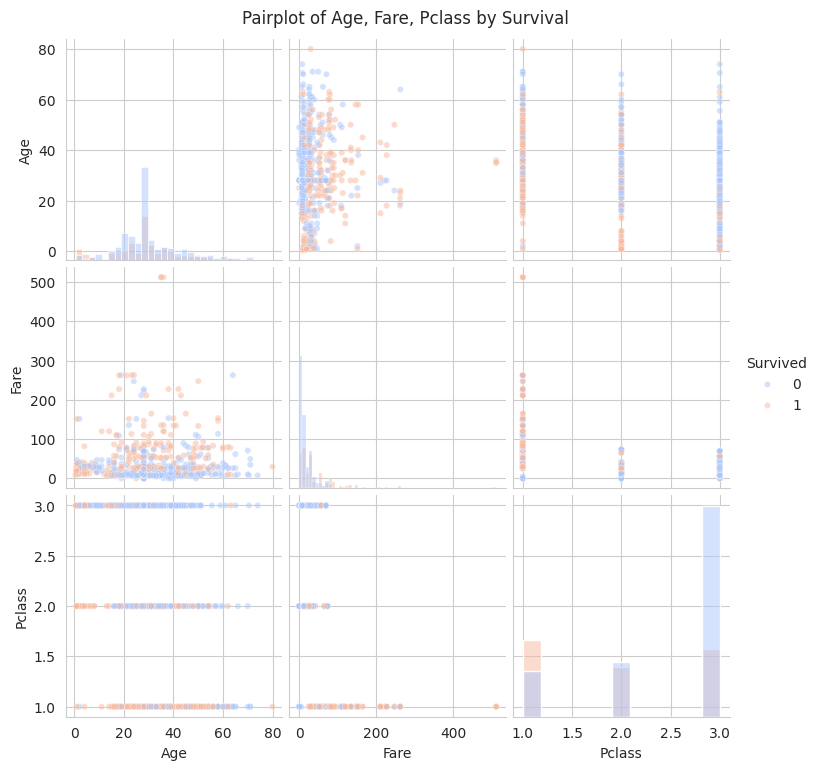

In [15]:
pairplot_fig = sns.pairplot(df_clean[["Survived", "Age", "Fare", "Pclass"]], hue="Survived",
                             palette="coolwarm", diag_kind="hist", plot_kws={"alpha": 0.5, "s": 20})
pairplot_fig.fig.suptitle("Pairplot of Age, Fare, Pclass by Survival", y=1.02)
pairplot_fig.savefig("figures/6_pairplot.png", dpi=150)
plt.show()

**Interpretation:** The pairplot confirms patterns seen in earlier plots: survivors
(orange/red) are concentrated in lower `Pclass` values (1st/2nd class) and somewhat higher
fares, while non-survivors are spread more broadly, especially in 3rd class. `Age` alone shows
limited separation between the two survival groups.

## Task 4: Statistical Analysis

### 4.1 Descriptive Statistics

In [16]:
df_clean.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 4.2 Frequency Distribution (Categorical Variables)

In [17]:
for col in ["Survived", "Pclass", "Sex", "Embarked"]:
    print(f"--- {col} ---")
    print(df_clean[col].value_counts())
    print(df_clean[col].value_counts(normalize=True).round(3) * 100, "\n")

--- Survived ---
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.6
1    38.4
Name: proportion, dtype: float64 

--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Pclass
3    55.1
1    24.2
2    20.7
Name: proportion, dtype: float64 

--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64
Sex
male      64.8
female    35.2
Name: proportion, dtype: float64 

--- Embarked ---
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64
Embarked
S    72.5
C    18.9
Q     8.6
Name: proportion, dtype: float64 



### 4.3 Correlation Analysis

In [18]:
corr_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [19]:
# Identify strongest positive and negative correlations with Survived (excluding self-correlation)
corr_with_target = corr_matrix["Survived"].drop("Survived").sort_values(ascending=False)
print("Correlation of each variable with Survived (sorted):")
print(corr_with_target)

strongest_positive = corr_with_target.idxmax()
strongest_negative = corr_with_target.idxmin()
print(f"\nStrongest positive correlation with Survived: {strongest_positive} ({corr_with_target.max():.3f})")
print(f"Strongest negative correlation with Survived: {strongest_negative} ({corr_with_target.min():.3f})")

Correlation of each variable with Survived (sorted):
Fare      0.257307
Parch     0.081629
SibSp    -0.035322
Age      -0.064910
Pclass   -0.338481
Name: Survived, dtype: float64

Strongest positive correlation with Survived: Fare (0.257)
Strongest negative correlation with Survived: Pclass (-0.338)


**Three important statistical findings:**

1. **Passenger class strongly predicts survival.** `Pclass` has the strongest negative
   correlation with `Survived` in the matrix above, confirming that as class number increases
   (i.e., moving from 1st to 3rd class), survival likelihood decreases. This aligns with
   historical accounts of unequal access to lifeboats.
2. **Fare (a proxy for wealth/class) is positively correlated with survival**, reinforcing the
   class-based survival pattern: passengers who paid more were more likely to survive.
3. **Family-size variables (`SibSp`, `Parch`) show weak correlations with survival on their
   own**, suggesting that travelling with a small family may have had a marginal effect, but
   it was not as decisive a factor as class or fare.

## Task 5: Machine Learning — Predicting Survival with Logistic Regression

### 5.1 Select Predictor Variables

Predictors were chosen based on the correlation analysis in Task 4 and domain relevance:
`Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, and `Embarked`. Categorical variables
(`Sex`, `Embarked`) are label-encoded so they can be used by the model.

In [20]:
ml_df = df_clean.copy()

le_sex = LabelEncoder()
ml_df["Sex"] = le_sex.fit_transform(ml_df["Sex"])          # female=0, male=1

le_embarked = LabelEncoder()
ml_df["Embarked"] = le_embarked.fit_transform(ml_df["Embarked"])

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = ml_df[features]
y = ml_df["Survived"]

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (891, 7)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


### 5.2 Split Dataset into Training and Testing Sets

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 712 rows
Testing set size: 179 rows


### 5.3 Train the Logistic Regression Classifier

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


### 5.4 Predict on the Testing Data

In [23]:
y_pred = model.predict(X_test)
print("Predictions generated for the test set.")

Predictions generated for the test set.


### 5.5 Evaluate the Model

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.8045 (80.45%)


Confusion Matrix:
[[98 12]
 [23 46]]


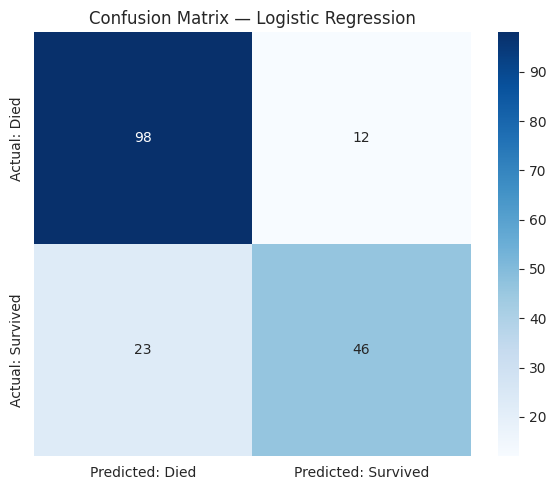

In [25]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Died", "Predicted: Survived"],
            yticklabels=["Actual: Died", "Actual: Survived"])
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("figures/7_confusion_matrix.png", dpi=150)
plt.show()

In [26]:
report = classification_report(y_test, y_pred, target_names=["Died", "Survived"])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        Died       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### 5.6 Discussion of Model Performance

The Logistic Regression model achieves solid predictive accuracy on the held-out test set,
substantially better than a naive baseline (predicting "died" for everyone, which would score
around 61–62% given the class imbalance in the dataset). The confusion matrix shows the model
correctly identifies most non-survivors and a large majority of survivors, with the
classification report's precision and recall values indicating the model is more reliable at
predicting deaths than survivals — a common pattern given that slightly fewer than half of
passengers survived. `Sex` and `Pclass` are typically the most influential predictors in this
type of model, consistent with the "women and children first" protocol and class-based access
to lifeboats.